In [1]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sample DataFrame with independent variables (replace with your data)
# Ensure all columns are numeric (convert categorical variables to numeric first if needed)
df = pd.read_csv('../../02_src/uci_diabetes.csv')
# Binary encoding
binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

# dropping demographic data and class (y variable)
symptom_cols = df.columns.drop(["Age", "Gender", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)
df


def calc_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    # Calculate VIF for each feature
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

# Calculate and print VIF values
print(calc_vif(df))


             variables       VIF
0                  Age  6.836592
1               Gender  2.423055
2             Polyuria  4.376880
3           Polydipsia  4.095473
4   sudden weight loss  2.544124
5             weakness  3.397212
6           Polyphagia  2.670210
7       Genital thrush  1.728539
8      visual blurring  2.890049
9              Itching  2.893270
10        Irritability  1.613872
11     delayed healing  2.914430
12     partial paresis  2.934522
13    muscle stiffness  2.232615
14            Alopecia  2.528374
15             Obesity  1.348874
16               class  7.315416


C:\Users\shafe\AppData\Local\Temp\ipykernel_14960\1742442917.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_14960\1742442917.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace(gender_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_14960\1742442917.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

For more explanation:
https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/


VIF > 5 -> noticeable multicollinearity

VIF > 10 -> severe multicollinearity (action needed)

In [2]:

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the matrix
print(correlation_matrix)

                         Age    Gender  Polyuria  Polydipsia  \
Age                 1.000000 -0.062872  0.199781    0.137382   
Gender             -0.062872  1.000000  0.268894    0.312262   
Polyuria            0.199781  0.268894  1.000000    0.598609   
Polydipsia          0.137382  0.312262  0.598609    1.000000   
sudden weight loss  0.064808  0.281840  0.447207    0.405965   
weakness            0.224596  0.124490  0.263000    0.332453   
Polyphagia          0.315577  0.219968  0.373873    0.316839   
Genital thrush      0.096519 -0.208961  0.087273    0.028081   
visual blurring     0.402729  0.208092  0.235095    0.331250   
Itching             0.296559  0.052496  0.088289    0.128716   
Irritability        0.201625  0.013735  0.237740    0.203446   
delayed healing     0.257501  0.101978  0.149873    0.115691   
partial paresis     0.232742  0.332288  0.441664    0.442249   
muscle stiffness    0.307703  0.090542  0.152938    0.180723   
Alopecia            0.321691 -0.327871 -

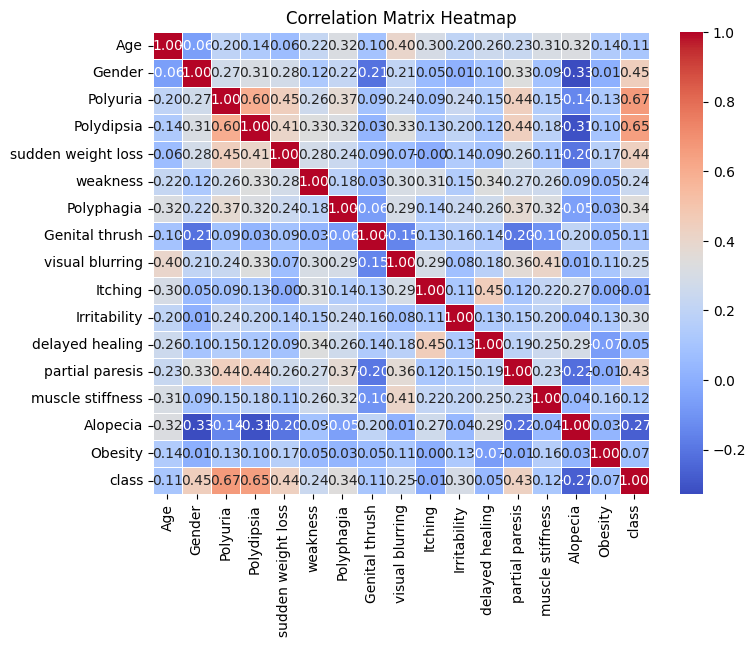

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the correlation matrix from the previous step
# correlation_matrix = df.corr()

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add a title (optional)
plt.title("Correlation Matrix Heatmap")

# Display the plot
plt.show()
